1.  Can we use Bagging for regression problems?

Ans. yes Bagging can be used for both regression as well as classification problem.

2.  What is the difference between multiple model training and single model training?

Ans. The difference between **multiple model training** and **single model training** lies in how many models are trained and how they are used for decision-making.

### **Single Model Training**
- Trains only one model on the dataset.
- Used when a single algorithm is expected to perform well for the given problem.
- Computationally less expensive.
- Easier to interpret and deploy.
- Example: Training a single Random Forest model for fraud detection.

### **Multiple Model Training**
- Trains multiple models, either of the same type with different hyperparameters or different types of models.
- Used to improve accuracy, generalizability, or robustness.
- Computationally expensive as multiple models need to be trained and evaluated.
- Can be combined using **ensemble methods** (bagging, boosting, stacking) or **comparative selection** (choosing the best model).
- Example: Training Random Forest, XGBoost, and Neural Networks for fraud detection and selecting the best performer.


3. Explain the concept of feature randomness in Random Forest.

Ans. ### **Feature Randomness in Random Forest**  
Feature randomness in **Random Forest** refers to the technique of selecting a random subset of features at each decision split within a tree. This enhances the model’s diversity and reduces overfitting.

### **How Feature Randomness Works**  
1. **Random Feature Selection Per Split**  
   - In standard decision trees, all features are considered when selecting the best split.  
   - In Random Forest, at each split, only a **random subset** of features is considered.  
   - This ensures different trees in the forest make different decisions, increasing diversity.

2. **Controlled by `max_features` Hyperparameter**  
   - Determines how many features are randomly chosen at each split.  
   - Common values:
     - `sqrt(n_features)`: Default for classification (square root of total features).
     - `log2(n_features)`: Another common option.
     - `n_features`: Uses all features (reduces randomness, similar to a single tree).

3. **Impact on Model Performance**  
   - **Reduces Overfitting**: Different trees rely on different feature subsets, making the model more generalizable.  
   - **Improves Robustness**: If one feature is noisy, some trees will still learn meaningful patterns.  
   - **Balances Bias-Variance Tradeoff**: More randomness increases bias but reduces variance.


4.  What is OOB (Out-of-Bag) Score?

Ans. ### **Out-of-Bag (OOB) Score in Random Forest**  
The **Out-of-Bag (OOB) score** is a built-in validation metric in **Random Forest**, used to estimate model performance **without needing a separate validation set**.

### **How OOB Works**  
1. **Bootstrap Sampling**:  
   - Each tree in the Random Forest is trained on a **random bootstrap sample** (sampling with replacement) of the dataset.  
   - About **63%** of the data is included in each tree’s training set, while **37% remains unseen** (OOB data).  

2. **OOB Prediction**:  
   - Each data point is **left out** from some trees (OOB trees).  
   - These trees make predictions for the left-out samples.  
   - The final OOB prediction is the majority vote (classification) or average prediction (regression).  

3. **OOB Score Calculation**:  
   - **For classification**: Percentage of correctly predicted OOB samples.  
   - **For regression**: Mean squared error (MSE) of OOB predictions.  

### **Why is OOB Score Useful?**  
✔ **No Need for a Separate Validation Set** – Saves data for training.  
✔ **Prevents Overfitting** – Provides an unbiased performance estimate.  
✔ **Faster Model Evaluation** – Eliminates the need for cross-validation.  


5. How can you measure the importance of features in a Random Forest model?

Ans. ### **Measuring Feature Importance in Random Forest**  
Feature importance in **Random Forest** helps identify which features contribute the most to the model’s predictions. There are two main methods:

---

### **1. Mean Decrease in Impurity (MDI) – Gini Importance**
- Based on the **Gini Impurity** or **variance reduction** in decision trees.
- A feature’s importance is computed by **averaging the reduction in impurity** across all splits where the feature is used.
- Higher importance means the feature **contributes more to decision-making**.

✔ **Pros:** Fast to compute.  
❌ **Cons:** Biased toward high-cardinality features.

---

### **2. Mean Decrease in Accuracy (MDA) – Permutation Importance**
- Measures how much a feature contributes to model accuracy by **randomly shuffling** its values and checking the performance drop.
- Steps:
  1. Compute the baseline accuracy (or R² for regression).
  2. Shuffle values of a single feature while keeping others intact.
  3. Recalculate accuracy. A large drop means the feature is important.

✔ **Pros:** More reliable, accounts for feature interactions.  
❌ **Cons:** Computationally expensive.

---

### **Which Method to Use?**  
- **MDI (Gini Importance)**: Use for quick insights but be cautious of bias.  
- **MDA (Permutation Importance)**: Preferred for robust feature selection.


6. Explain the working principle of a Bagging Classifier

### **Working Principle of a Bagging Classifier**  
A **Bagging Classifier (Bootstrap Aggregating Classifier)** is an ensemble learning method that improves accuracy and reduces overfitting by training multiple models on different subsets of data and combining their predictions.  

---

### **How Bagging Works**  

#### **1. Bootstrap Sampling (Random Subsets of Data)**
- Given a dataset of **N** samples, multiple base models (weak learners) are trained.
- Each model gets a **random bootstrap sample** (sampling with replacement).
- Some samples may appear multiple times, while others may be left out.

#### **2. Individual Model Training**
- Each model (often a Decision Tree) is trained independently on its bootstrap sample.
- Models learn different patterns due to different subsets of data.

#### **3. Aggregation of Predictions**
- For **classification**, majority voting is used (most common class wins).  
- For **regression**, predictions are averaged.

---

### **Advantages of Bagging**
✔ **Reduces Overfitting** – Each model learns different aspects of the data.  
✔ **Improves Stability** – Less sensitive to noise in the dataset.  
✔ **Works Well with High-Variance Models** – Decision Trees benefit the most.

---

### **Bagging Classifier in Random Forest**
- **Random Forest = Bagging + Feature Randomness**  
- Random Forest extends Bagging by also randomly selecting **features** at each split.


7.  How do you evaluate a Bagging Classifier’s performance?

Ans. ### **Evaluating a Bagging Classifier’s Performance**  
To assess how well a **Bagging Classifier** performs, we use multiple evaluation metrics depending on the problem type (classification or regression).  

---

### **1. Accuracy-Based Metrics (For Classification)**
✅ **Accuracy** – Measures overall correctness.  
\[
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
\]  
✅ **Precision, Recall, and F1-Score** – Useful for imbalanced datasets.  
- **Precision**: How many predicted positives are actually correct?  
- **Recall (Sensitivity)**: How many actual positives are correctly identified?  
- **F1-Score**: Harmonic mean of Precision & Recall (balances both).  

✅ **ROC-AUC (Receiver Operating Characteristic - Area Under Curve)**  
- Measures the classifier's ability to distinguish between classes.  
- Higher **AUC** means better performance.  

✅ **Confusion Matrix**  
- Shows true vs. predicted labels for detailed analysis.  

---

### **2. Error-Based Metrics (For Regression)**
✅ **Mean Squared Error (MSE) / Root Mean Squared Error (RMSE)** – Measures average squared prediction error.  
✅ **Mean Absolute Error (MAE)** – Measures average absolute prediction error.  
✅ **R² Score (Coefficient of Determination)** – Measures how well predictions match actual values.  

---

### **3. Out-of-Bag (OOB) Score (Unique to Bagging)**
- Uses **samples not included** in each bootstrap training set to estimate generalization performance.  
- Helps avoid separate validation sets.  
- **Higher OOB Score = Better Model Performance.**  


8.  How does a Bagging Regressor work?

Ans. ### **How a Bagging Regressor Works**  
A **Bagging Regressor** is an ensemble learning technique that improves prediction accuracy and reduces variance by combining multiple regression models trained on different subsets of data.

---

### **Working Principle**  

#### **1. Bootstrap Sampling (Data Resampling)**
- Given a dataset of **N** samples, the algorithm creates **M** random bootstrap samples (sampling with replacement).
- Each sample may contain duplicate observations, and some original data points may be excluded.

#### **2. Training Individual Regressors**
- Each bootstrap sample is used to train an **independent regression model** (e.g., Decision Tree Regressor, Linear Regression, etc.).
- Different models capture different patterns due to diverse training data.

#### **3. Aggregation of Predictions**
- Once all regressors are trained, their predictions are combined.
- **Final Prediction = Average of all individual predictions**  
  \[
  \hat{y} = \frac{1}{M} \sum_{i=1}^{M} \hat{y_i}
  \]
- Averaging reduces variance and improves generalization.

---

### **Advantages of Bagging Regressor**
✔ **Reduces Overfitting** – Smoothens predictions by averaging multiple models.  
✔ **More Stable Predictions** – Less affected by data noise.  
✔ **Handles Complex Relationships** – Works well with high-variance models (e.g., Decision Trees).  


9. What is the main advantage of ensemble techniques

Ans. ### **Main Advantage of Ensemble Techniques**  
The primary advantage of **ensemble techniques** is that they **combine multiple models** to improve accuracy, stability, and robustness compared to individual models.  

### **Key Benefits:**  

✅ **Higher Accuracy** – Aggregating multiple models reduces errors and improves predictive performance.  

✅ **Reduced Overfitting** – Methods like **Bagging** decrease variance, making models more generalizable.  

✅ **Better Generalization** – Ensemble models perform well on unseen data compared to single models.  

✅ **Handles Noisy Data** – Outliers or noisy samples have less impact when multiple models contribute to predictions.  

✅ **Works for Complex Patterns** – Can model nonlinear relationships better than individual models.  



10.  What is the main challenge of ensemble methods?

Ans. ### **Main Challenges of Ensemble Methods**  

While ensemble methods improve performance, they come with certain challenges:  

---

### **1. Higher Computational Cost** ⚡  
- Training multiple models requires more memory and processing power.  
- Techniques like **Boosting** (e.g., XGBoost) can be slow, especially with large datasets.  

### **2. Complexity in Interpretation** 🧩  
- Ensembles (especially Stacking and Boosting) are harder to interpret than single models.  
- Unlike Decision Trees or Linear Regression, it’s difficult to explain **why** a prediction was made.  

### **3. Risk of Overfitting** 🎯  
- If not tuned properly, ensembles (especially **Boosting**) can overfit the training data.  
- Requires careful hyperparameter tuning (e.g., learning rate, number of estimators).  

### **4. Difficult Deployment & Maintenance** 🚀  
- A single model is easier to deploy and update.  
- Ensemble models (with multiple sub-models) require more storage and inference time.  


11.  Explain the key idea behind ensemble techniques

Ans. ### **Key Idea Behind Ensemble Techniques**  

The fundamental idea of **ensemble techniques** is to **combine multiple models** to create a stronger, more accurate, and more robust predictive model than any single model alone.  

---

### **Why Does Ensemble Learning Work?**  

1️⃣ **Reduces Bias & Variance** – Combining models helps **reduce errors** from individual models.  
   - **Bagging** (e.g., Random Forest) reduces variance.  
   - **Boosting** (e.g., XGBoost) reduces bias.  

2️⃣ **Improves Generalization** – Multiple models learn different patterns, making the final model more **resistant to overfitting**.  

3️⃣ **Handles Noisy Data** – Outliers or noisy data points have less impact when predictions are averaged or voted on.  

4️⃣ **Boosts Accuracy** – Even weak models (Decision Stumps, simple trees) can achieve high accuracy when combined effectively.  

---

### **Common Ensemble Methods**  

🔹 **Bagging (Bootstrap Aggregating)** – Trains multiple models on different bootstrap samples and averages their predictions.  
   - Example: **Random Forest**  

🔹 **Boosting** – Sequentially trains models, giving more weight to misclassified points.  
   - Example: **XGBoost, AdaBoost**  

🔹 **Stacking** – Trains multiple models and combines their outputs using a meta-model.  
   - Example: Combining **Logistic Regression, SVM, and Decision Trees** for final prediction.  


12. What is a Random Forest Classifier.

Ans. ### **Random Forest Classifier** 🌳🌲  

A **Random Forest Classifier** is an **ensemble learning algorithm** that combines multiple **Decision Trees** to improve accuracy, reduce overfitting, and enhance generalization.

---

### **How It Works** 🛠️  

1️⃣ **Bootstrap Sampling (Bagging)**  
   - The dataset is randomly **sampled with replacement** to create multiple training subsets.  
   - Each subset is used to train an **individual Decision Tree** independently.  

2️⃣ **Feature Randomness (Split Selection)**  
   - At each tree split, only a **random subset of features** is considered (controlled by `max_features`).  
   - This ensures diversity among trees, reducing correlation between them.  

3️⃣ **Voting for Final Prediction** 🗳️  
   - Each tree predicts a class label.  
   - The **majority vote** is taken as the final classification.  

---

### **Advantages of Random Forest** ✅  

✔ **Higher Accuracy** – Reduces variance and overfitting compared to a single Decision Tree.  
✔ **Handles Missing Data & Noisy Features** – More robust to imperfect datasets.  
✔ **Feature Importance Ranking** – Can determine which features contribute the most to predictions.  
✔ **Works Well with Large Datasets** – Efficient even with high-dimensional data.  

---

### **Hyperparameters to Tune 🎛️**  
- `n_estimators`: Number of trees in the forest.  
- `max_features`: Number of features considered at each split.  
- `max_depth`: Limits tree depth to prevent overfitting.  
- `min_samples_split`: Minimum samples required to split a node.  



13. What are the main types of ensemble techniques

Ans. ### **Main Types of Ensemble Techniques**  

Ensemble methods combine multiple models to improve accuracy, reduce overfitting, and increase robustness. The three main types are:  

---

### **1️⃣ Bagging (Bootstrap Aggregating) 🌳**  
- **Goal:** Reduce variance and prevent overfitting by training multiple independent models on different random subsets of data.  
- **How It Works:**  
  - Creates **bootstrap samples** (sampling with replacement).  
  - Trains **multiple models in parallel** (usually Decision Trees).  
  - Aggregates predictions using **majority voting (classification)** or **averaging (regression)**.  
- **Example:**  
  - **Random Forest** (Bagging applied to Decision Trees).  

✔ **Best for:** High-variance models (e.g., Decision Trees).  

---

### **2️⃣ Boosting 🚀**  
- **Goal:** Reduce bias by training models sequentially, with each model focusing on correcting errors from the previous one.  
- **How It Works:**  
  - Starts with a simple model.  
  - Each subsequent model gives **higher weight to misclassified samples**.  
  - Predictions are combined (weighted sum or majority vote).  
- **Examples:**  
  - **AdaBoost** – Assigns higher weights to misclassified points.  
  - **Gradient Boosting (XGBoost, LightGBM, CatBoost)** – Uses gradient descent to minimize loss.  

✔ **Best for:** Improving weak models (e.g., shallow trees, logistic regression).  

---

### **3️⃣ Stacking 🏗️**  
- **Goal:** Combine diverse models to create a more powerful meta-model.  
- **How It Works:**  
  - Trains multiple base models (e.g., Random Forest, SVM, Neural Network).  
  - The outputs of base models are used as **inputs to a meta-model** (e.g., Logistic Regression).  
- **Example:**  
  - **Stacked Generalization** – Uses a meta-classifier to make final predictions.  

✔ **Best for:** Combining models with different strengths for superior performance.  

---

### **Comparison Table 🏆**  

| **Technique** | **Goal** | **How It Works** | **Best Used For** |  
|-------------|-----------|----------------|------------------|  
| **Bagging** | Reduce variance | Parallel training, majority voting/averaging | High-variance models like Decision Trees |  
| **Boosting** | Reduce bias | Sequential training, weighted corrections | Weak models like Decision Stumps |  
| **Stacking** | Combine strengths | Meta-model learns from base models | Diverse model ensembles |  

W

14.  What is ensemble learning in machine learning.

Ans. ### **What is Ensemble Learning in Machine Learning?**  

🔹 **Ensemble Learning** is a technique that **combines multiple models** to improve overall prediction accuracy, reduce overfitting, and enhance model robustness. Instead of relying on a single model, ensemble methods aggregate predictions from several models to make better decisions.  

---

### **Why Use Ensemble Learning?**  
✔ **Higher Accuracy** – Multiple models make fewer mistakes than a single model.  
✔ **Reduces Overfitting** – Helps generalize better on unseen data.  
✔ **Handles Noisy Data** – Less sensitive to outliers and noise.  
✔ **Boosts Weak Models** – Even simple models (weak learners) can be combined to make strong predictions.  

---

### **Types of Ensemble Learning**  

1️⃣ **Bagging (Bootstrap Aggregating) 🌳**  
   - Reduces variance by training multiple models on **random subsets** of data.  
   - Each model makes a prediction, and the final result is **majority voting (classification)** or **averaging (regression)**.  
   - **Example:** **Random Forest** (ensemble of Decision Trees).  

2️⃣ **Boosting 🚀**  
   - Reduces bias by training models **sequentially**, focusing on **misclassified samples**.  
   - Later models correct errors made by earlier ones.  
   - **Example:** **AdaBoost, Gradient Boosting (XGBoost, LightGBM, CatBoost)**.  

3️⃣ **Stacking 🏗️**  
   - Combines different types of models and uses a **meta-model** to make final predictions.  
   - The meta-model learns from the outputs of the base models.  
   - **Example:** Using **Random Forest, SVM, and Neural Networks** together.  

---

### **Comparison Table 🏆**  

| **Ensemble Type** | **How It Works** | **Best For** | **Example Model** |  
|-----------------|----------------|------------|--------------|  
| **Bagging** | Parallel training, averaging or voting | High-variance models | Random Forest |  
| **Boosting** | Sequential training, error correction | Weak models, reducing bias | XGBoost, AdaBoost |  
| **Stacking** | Meta-model combines multiple models | Combining different algorithms | Stacked Generalization |  


15. When should we avoid using ensemble methods

Ans. ### **When Should We Avoid Using Ensemble Methods?** 🚫  

While ensemble methods improve accuracy, they **aren’t always the best choice** in certain situations. Here are key cases where you might want to avoid using them:  

---

### **1️⃣ When Interpretability is Critical** 🧐  
- Ensemble models (especially **Random Forest, XGBoost, and Stacking**) are complex and hard to interpret.  
- If you need **clear decision rules** (e.g., in healthcare, finance, or legal applications), simpler models like **Logistic Regression or Decision Trees** are better.  

📌 **Use Instead:** Linear models, Decision Trees  

---

### **2️⃣ When Computational Resources are Limited** ⚡  
- Ensemble methods (especially **Boosting** and **Stacking**) require significant computational power.  
- If your system has limited **CPU, memory, or time constraints**, simpler models are preferable.  

📌 **Use Instead:** A well-tuned single model (e.g., a single Decision Tree or SVM).  

---

### **3️⃣ When Training Data is Small 📉**  
- **Boosting methods** like XGBoost and AdaBoost work best with large datasets.  
- **Overfitting risk** is high when using ensembles on small datasets.  

📌 **Use Instead:** A single model with **regularization** (e.g., Ridge Regression, SVM).  

---

### **4️⃣ When a Single Model Already Performs Well** 🎯  
- If a single model (e.g., **a well-tuned Logistic Regression or Decision Tree**) already gives high accuracy, adding an ensemble may not provide significant improvements.  

📌 **Use Instead:** Optimize hyperparameters of the single model.  

---

### **5️⃣ When Deployment Needs to Be Fast & Lightweight 🚀**  
- **Ensemble models take longer to make predictions**, making them **less ideal for real-time applications** (e.g., fraud detection, chatbots).  
- Large ensembles also **increase storage and maintenance complexity**.  

📌 **Use Instead:** A compact, optimized model (e.g., a pruned Decision Tree or a neural network with distillation).  

---

### **Final Takeaway**  
🚨 **Avoid Ensemble Methods When:**  
✅ You need interpretability.  
✅ You have limited computational resources.  
✅ Your dataset is too small.  
✅ A single model already performs well.  
✅ You need ultra-fast deployment.  


16. How does Bagging help in reducing overfitting?

Ans. ### **How Does Bagging Reduce Overfitting?**  

**Bagging (Bootstrap Aggregating)** is an ensemble technique that helps reduce overfitting by decreasing variance while maintaining low bias. It achieves this by training multiple models on different subsets of data and then aggregating their predictions.  

---

### **Key Ways Bagging Reduces Overfitting:**  

1️⃣ **Reduces Variance by Averaging Predictions** 🎯  
   - Overfitting occurs when a model learns noise from the training data.  
   - Bagging trains multiple models on different **random subsets** (bootstrapped samples).  
   - Since these models are trained on **slightly different data**, their errors tend to cancel out.  
   - **Final prediction = Average (regression) or Majority Vote (classification)** → Less prone to overfitting.  

2️⃣ **Reduces Sensitivity to Noisy Data** 🔇  
   - Individual models may overfit to noisy patterns.  
   - In Bagging, each model sees **only a portion** of the training data, making them **less sensitive** to specific noise.  

3️⃣ **Creates Diverse Models via Feature Randomness** 🔀  
   - Some implementations (e.g., **Random Forest**) introduce **random feature selection**, ensuring that each model focuses on different patterns.  
   - This prevents a single dominant feature from driving the entire prediction.  

4️⃣ **Limits Overfitting of Complex Models (e.g., Decision Trees)** 🌳  
   - Deep Decision Trees tend to overfit by memorizing training data.  
   - Bagging **reduces their reliance on specific samples**, leading to better generalization.  

---

### **Example: Bagging vs. Single Decision Tree**  

| **Model** | **Overfitting Risk** | **Generalization** |  
|-----------|-----------------|-----------------|  
| Single Decision Tree | High | Poor |  
| Bagging with Trees (Random Forest) | Low | Good |  

---

### **Final Takeaway** 🚀  
✅ **Bagging prevents overfitting** by averaging multiple models, reducing variance, and improving generalization.  
✅ **Best for high-variance models** (e.g., Decision Trees).  
✅ **Works well when data has noise or irrelevant features.**  


17. Why is Random Forest better than a single Decision Tree

Ans. ### **Why is Random Forest Better Than a Single Decision Tree?** 🌳🌲  

**Random Forest** is an ensemble of multiple **Decision Trees**, making it more **accurate, robust, and generalizable** compared to a single Decision Tree.  

---

### **Key Advantages of Random Forest Over a Single Decision Tree**  

### **1️⃣ Reduces Overfitting (Better Generalization)** 🎯  
- **Decision Trees** tend to overfit, especially when deep.  
- **Random Forest** reduces overfitting by averaging multiple trees, making it more **robust** on unseen data.  

📌 **Example:** A single deep tree memorizes the training data, while a Random Forest smooths predictions by combining multiple trees.  

---

### **2️⃣ Less Sensitive to Noise & Outliers** 🔇  
- A **single Decision Tree** can be highly influenced by outliers.  
- **Random Forest**, by averaging multiple trees, reduces the impact of noisy data points.  

---

### **3️⃣ Handles Feature Importance & Selection** 🔀  
- **Random Forest** randomly selects subsets of **features** at each split, ensuring no single feature dominates the decision-making.  
- This leads to more **diverse and balanced trees** compared to a single Decision Tree.  

---

### **4️⃣ More Stable & Consistent Predictions** 🏆  
- A **single Decision Tree** can change significantly with small changes in data.  
- **Random Forest** is more stable because multiple trees contribute to the final prediction.  

📌 **Example:** In real-world data, minor variations won’t drastically change a Random Forest’s prediction, unlike a single tree.  

---

### **5️⃣ Works Well for Large & High-Dimensional Data** 📊  
- **Random Forest** can efficiently handle large datasets and high-dimensional spaces.  
- A **single Decision Tree** might struggle with complex relationships.  

---

### **Comparison Table: Random Forest vs. Decision Tree**  

| **Feature**            | **Decision Tree** 🌲 | **Random Forest** 🌳🌳🌳 |  
|------------------------|---------------------|---------------------|  
| **Overfitting**        | High 🟥             | Low ✅             |  
| **Stability**          | Sensitive to changes | Stable ✅          |  
| **Handling Noise**     | Poor 🟥             | Good ✅            |  
| **Feature Importance** | Uses all features    | Random selection ✅ |  
| **Performance on Large Data** | Struggles 🚨 | Handles well ✅ |  

---

### **Final Takeaway 🚀**  
✅ **Random Forest is better than a single Decision Tree** because it reduces overfitting, is more stable, handles noise better, and generalizes well.  
✅ **Best for high-variance problems** where decision trees tend to overfit.  


18. What is the role of bootstrap sampling in Bagging

Ans. ### **Role of Bootstrap Sampling in Bagging** 🎯  

**Bootstrap Sampling** is a key technique in **Bagging (Bootstrap Aggregating)** that helps create diverse models, reducing variance and improving generalization.  

---

### **How Bootstrap Sampling Works in Bagging**  

1️⃣ **Random Sampling with Replacement** 🔀  
   - Each model in the ensemble is trained on a **random subset of the dataset**, drawn **with replacement** (some data points appear multiple times, while others may be left out).  
   
2️⃣ **Diversity in Training Data** 📊  
   - Since each base model gets a different subset, they learn **slightly different patterns**, reducing overfitting.  

3️⃣ **Independent Model Training** 🏗️  
   - Each model (e.g., Decision Tree) is trained separately and makes independent predictions.  

4️⃣ **Final Prediction by Aggregation** 🗳️  
   - The predictions are combined using:  
     - **Majority voting** (for classification).  
     - **Averaging** (for regression).  

---

### **Why Bootstrap Sampling Helps in Bagging**  

✅ **Reduces Overfitting** – Prevents individual trees from memorizing the training data.  
✅ **Improves Model Stability** – Since each model sees different data, errors are not correlated.  
✅ **Reduces Variance** – Averaging predictions smooths fluctuations from individual models.  
✅ **Handles Noisy & Imbalanced Data** – Some models may focus on underrepresented samples.  

---

### **Example: Bootstrap Sampling in Action**  

Suppose we have **1000 training samples**:  
- We generate **10 bootstrapped datasets** of **1000 samples each**, but since sampling is **with replacement**, some samples are repeated while others are left out.  
- Each dataset trains one Decision Tree.  
- Final prediction is based on the aggregation of all trees (e.g., **majority vote** in classification).  

---

### **Final Takeaway 🚀**  
**Bootstrap Sampling ensures diversity among models in Bagging**, making the final ensemble more **stable, robust, and generalizable** compared to a single model.  


19. What are some real-world applications of ensemble techniques

Ans. ### **Real-World Applications of Ensemble Techniques** 🌎🚀  

Ensemble methods like **Bagging, Boosting, and Stacking** are widely used in various industries to enhance model accuracy, robustness, and generalization. Here are some key applications:  

---

### **1️⃣ Fraud Detection (Finance & Banking) 💳🔍**  
- **Challenge:** Fraudulent transactions are rare but costly.  
- **Solution:**  
  - **Random Forest & XGBoost** help detect fraud by combining patterns from different models.  
  - **Boosting** (e.g., XGBoost) is effective in handling imbalanced data.  
- **Example:** Credit card fraud detection using ensemble classifiers.  

✅ **Best Methods:** Random Forest, XGBoost, Stacking  

---

### **2️⃣ Sales Prediction & Demand Forecasting (Retail & E-commerce) 📈🛍️**  
- **Challenge:** Sales fluctuate due to seasonality, trends, and external factors.  
- **Solution:**  
  - **Bagging & Gradient Boosting (LightGBM, XGBoost)** improve forecasting by aggregating multiple models.  
- **Example:** Amazon & Walmart use ensemble models to predict inventory demand.  

✅ **Best Methods:** XGBoost, LightGBM, Random Forest  

---

### **3️⃣ Healthcare & Medical Diagnosis 🏥🩺**  
- **Challenge:** Accurate diagnosis based on complex patient data.  
- **Solution:**  
  - **Stacking models** (e.g., combining Decision Trees, Neural Networks, and SVMs) improves disease prediction.  
  - **Boosting methods** enhance accuracy in predicting heart disease and cancer.  
- **Example:** AI-based cancer detection using **Stacked Ensemble Learning**.  

✅ **Best Methods:** Stacking, XGBoost, Random Forest  

---

### **4️⃣ Customer Churn Prediction (Telecom & SaaS) 📞📊**  
- **Challenge:** Identifying customers likely to leave.  
- **Solution:**  
  - **Boosting models (XGBoost, AdaBoost)** find subtle patterns in customer behavior.  
  - **Bagging (Random Forest)** ensures robustness.  
- **Example:** Telecom companies (e.g., Verizon, AT&T) use ensembles to predict churn risk.  

✅ **Best Methods:** XGBoost, AdaBoost, Random Forest  

---

### **5️⃣ Image Recognition & Computer Vision 🖼️🔬**  
- **Challenge:** Identifying objects, faces, and scenes.  
- **Solution:**  
  - **Stacking Deep Learning models** (e.g., combining CNNs and Gradient Boosting).  
- **Example:** **Google Photos** and **Facebook** use ensembles for face recognition.  

✅ **Best Methods:** Stacking, CNN Ensembles  

---

### **6️⃣ NLP (Spam Detection & Sentiment Analysis) 📨😊☹️**  
- **Challenge:** Understanding human language accurately.  
- **Solution:**  
  - **Boosting & Stacking with NLP models** improve text classification.  
- **Example:** Gmail’s spam filter using **Random Forest + Gradient Boosting**.  

✅ **Best Methods:** XGBoost, Stacking  

---

### **7️⃣ Stock Market Prediction 📉💰**  
- **Challenge:** Financial data is noisy and volatile.  
- **Solution:**  
  - **Random Forest & XGBoost** analyze past patterns to make stock price predictions.  
- **Example:** Hedge funds use **ensemble learning** to predict market movements.  

✅ **Best Methods:** XGBoost, LightGBM, Random Forest  

---

### **Final Takeaway 🚀**  
Ensemble techniques are **powerful tools** in industries requiring **high accuracy, robustness, and generalization**.  



20. What is the difference between Bagging and Boosting?

Ans. ### **Bagging vs. Boosting: Key Differences** 🚀  

**Bagging (Bootstrap Aggregating) and Boosting** are both ensemble learning techniques, but they work differently in how they train models and combine predictions.  

---

### **🔹 1. Basic Concept**  

| **Technique**  | **Bagging** 🌳 | **Boosting** 🚀 |  
|---------------|--------------|--------------|  
| **Goal** | Reduce variance (overfitting) | Reduce bias (increase accuracy) |  
| **Model Training** | Trains models **independently** in parallel | Trains models **sequentially**, each correcting previous mistakes |  
| **Final Prediction** | Majority voting (classification) or averaging (regression) | Weighted combination of weak models |  

---

### **🔹 2. How They Work**  

### **1️⃣ Bagging: Random Subsets & Parallel Training**  
- **Each model is trained on a different random subset** (bootstrap sample) of the training data.  
- Models learn **independently** and are trained in **parallel**.  
- The final prediction is the **average (for regression)** or **majority vote (for classification)**.  
- **Example Algorithm:** **Random Forest** (ensemble of Decision Trees).  

✅ **Best for:** **Reducing variance**, preventing overfitting.  

---

### **2️⃣ Boosting: Sequential Training with Focus on Errors**  
- Models are trained **sequentially**, where each model focuses on the **mistakes of the previous model**.  
- Weak models (e.g., shallow Decision Trees) are combined to form a strong model.  
- **Higher weights** are given to misclassified samples to improve accuracy.  
- **Example Algorithms:** **AdaBoost, XGBoost, Gradient Boosting, LightGBM**.  

✅ **Best for:** **Reducing bias**, improving accuracy on complex data.  

---

### **🔹 3. Key Differences at a Glance**  

| **Feature**  | **Bagging** 🌳 | **Boosting** 🚀 |  
|------------|------------|------------|  
| **Training Strategy** | Models trained in **parallel** | Models trained **sequentially** |  
| **Focus** | Reduces **variance** (overfitting) | Reduces **bias** (error) |  
| **Data Sampling** | **Random subsets** from the dataset (bootstrap) | Trains on **entire dataset**, adjusting for errors |  
| **Model Independence** | Each model is **independent** | Later models depend on **previous models' mistakes** |  
| **Final Prediction** | **Averaging (regression) or majority vote (classification)** | Weighted combination of all models |  
| **Example Algorithms** | **Random Forest, Bagging Classifier** | **AdaBoost, XGBoost, LightGBM, Gradient Boosting** |  
| **Risk of Overfitting** | **Lower** (reduces variance) | **Higher** (if not tuned properly) |  
| **Computational Complexity** | **Lower** (parallel processing possible) | **Higher** (sequential training) |  

---

### **🔹 4. When to Use Bagging vs. Boosting?**  

✅ **Use Bagging When:**  
- The model **overfits** (high variance).  
- You have **unstable models** (e.g., Decision Trees).  
- **Random Forest** is a great choice.  

✅ **Use Boosting When:**  
- The model has **high bias** (underfitting).  
- You need **higher accuracy** on complex data.  
- **XGBoost, LightGBM, or AdaBoost** can be effective.  

---

### **Final Takeaway 🎯**  
- **Bagging = Reduces variance, prevents overfitting.**  
- **Boosting = Reduces bias, improves accuracy.**  
- **Bagging is simpler & faster** (Random Forest).  
- **Boosting is more powerful but needs careful tuning** (XGBoost, LightGBM).  


21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import make_classification

In [4]:
X,Y=make_classification(n_samples=500,n_features=10,n_classes=4,n_informative=4)

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.3, random_state=1)

In [7]:
from sklearn.ensemble import VotingClassifier

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [17]:
lg=LogisticRegression()
sv=SVC(kernel='rbf',C=0.6)
GB= GaussianNB()
tr=DecisionTreeClassifier(criterion='gini',max_depth=4,min_samples_split=4)

In [18]:
model=VotingClassifier(estimators=[('linear_regression',lg),('Support_vector',sv),('Gaussian',GB),('Decision_tree',tr)],voting='hard',verbose=True)

In [19]:
model.fit(X_train,Y_train)

[Voting] ........ (1 of 4) Processing linear_regression, total=   0.0s
[Voting] ........... (2 of 4) Processing Support_vector, total=   0.0s
[Voting] ................. (3 of 4) Processing Gaussian, total=   0.0s
[Voting] ............ (4 of 4) Processing Decision_tree, total=   0.0s


VotingClassifier(estimators=[('linear_regression', LogisticRegression()),
                             ('Support_vector', SVC(C=0.6)),
                             ('Gaussian', GaussianNB()),
                             ('Decision_tree',
                              DecisionTreeClassifier(max_depth=4,
                                                     min_samples_split=4))],
                 verbose=True)

In [20]:
Y_Predict= model.predict(X_test)

In [21]:
from sklearn.metrics import classification_report

In [22]:
print(classification_report(Y_Predict,Y_test))

              precision    recall  f1-score   support

           0       0.85      0.61      0.71        57
           1       0.50      0.56      0.53        32
           2       0.64      0.66      0.65        32
           3       0.40      0.55      0.46        29

    accuracy                           0.60       150
   macro avg       0.60      0.60      0.59       150
weighted avg       0.64      0.60      0.61       150



22.  Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE)

In [23]:
from sklearn.datasets import make_regression

In [40]:
X,Y_N=make_regression(n_samples=1000,n_features=6,n_informative=4,noise=1,random_state=1)

In [41]:
print(Y_N)

[-2.37435370e+01 -1.15368316e+02 -4.50390239e+01 -7.23640557e+00
  6.63075970e+01 -1.75431155e+02 -1.56214208e+02  8.47912176e+01
 -3.40609818e+00  1.50437690e+02 -5.39717523e+00 -2.54786000e+02
  1.03250659e+02 -6.79700486e+01  2.52130392e+02 -6.00624672e+01
 -1.41967328e+02  1.10580145e+02  7.39353311e+01  1.85057904e+01
 -1.22450230e+02  8.12631218e+01 -1.18899878e+01  1.13937545e+02
  1.93166479e+01 -1.23550978e+02  1.40810757e+02  1.17607276e+02
 -1.50024615e+02 -2.33778265e+02 -1.72586221e+02  2.04456689e+01
  1.68259712e+02  1.11813257e+02 -7.65349078e+01 -7.43893672e+01
 -3.07749243e+01  1.44186825e+02  4.33326821e+01 -2.10229646e+02
  4.73562905e+01 -5.98266376e+01 -7.58301514e+01  4.66122253e+01
  4.31993634e+01  1.81593891e+02 -9.14596794e+01  5.50543204e+01
  8.13545612e+01  7.49833246e+01 -2.87308589e+01 -8.55674986e+01
  9.55679287e+01 -2.98711174e+01 -6.01578157e+01  3.98367634e+01
 -5.24558679e+01 -7.02727153e+01  2.21205788e+02  4.55868687e+01
 -1.16409868e+02  1.73190

In [35]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y_N,test_size=0.3,random_state=1)

In [43]:
from sklearn.ensemble import BaggingRegressor

In [46]:
from sklearn.tree import DecisionTreeRegressor

In [47]:
tre=DecisionTreeRegressor(max_depth=5)

In [48]:
model=BaggingRegressor(estimator=tre,n_estimators=5,max_samples=0.7)

In [49]:
model.fit(X_train,Y_train)

BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=5), max_samples=0.7,
                 n_estimators=5)

In [50]:
Y_Predict= model.predict(X_test)

In [51]:
from sklearn.metrics import mean_squared_error

In [52]:
print(mean_squared_error(Y_Predict, Y_test))

1021.3788451000094


23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data=load_breast_cancer()

In [4]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
X=pd.DataFrame(data=data.data, columns=data.feature_names)

In [6]:
Y= data.target

In [7]:
from sklearn.model_selection  import train_test_split

In [8]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.3, random_state=1)

In [9]:
from sklearn.ensemble import RandomForestClassifier

In [25]:
model= RandomForestClassifier(n_estimators=5,criterion='entropy',max_depth=4,oob_score=True)

In [26]:
model.fit(X_train,Y_train)

RandomForestClassifier(criterion='entropy', max_depth=4, n_estimators=5,
                       oob_score=True)

In [14]:
model.feature_importances_

array([0.27115783, 0.01149776, 0.11947128, 0.00227815, 0.00645379,
       0.00796318, 0.02244975, 0.062924  , 0.        , 0.        ,
       0.01035975, 0.        , 0.01731627, 0.01034094, 0.00418745,
       0.        , 0.00853689, 0.00260645, 0.        , 0.01026222,
       0.01328569, 0.01173695, 0.07609431, 0.04457308, 0.02703396,
       0.05127045, 0.12619767, 0.05798886, 0.01199481, 0.0120185 ])

24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

In [15]:
from sklearn.tree import DecisionTreeClassifier

In [16]:
DT_model = DecisionTreeClassifier(criterion='gini',max_depth=5)

In [17]:
DT_model.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=5)

In [18]:
Y_pred_DT= DT_model.predict(X_test)

In [19]:
Y_pred=model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

In [ ]:
print(f'classification report of decision tree is following {classification_report(Y_pred_DT,Y_test)}')
print(f'classification report of random forest is following {classification_report(Y_pred,Y_test)}')

classification report of decision tree is following /n               precision    recall  f1-score   support

           0       0.89      0.98      0.93        57
           1       0.99      0.94      0.96       114

    accuracy                           0.95       171
   macro avg       0.94      0.96      0.95       171
weighted avg       0.96      0.95      0.95       171

classification report of random forest is following               precision    recall  f1-score   support

           0       0.87      0.90      0.89        61
           1       0.94      0.93      0.94       110

    accuracy                           0.92       171
   macro avg       0.91      0.91      0.91       171
weighted avg       0.92      0.92      0.92       171



25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier

In [27]:
model.oob_score_

0.8618090452261307

26. Train a Bagging Classifier using SVM as a base estimator and print accuracy

In [29]:
from sklearn.svm import SVC

In [30]:
from sklearn.ensemble import BaggingClassifier

In [31]:
model=BaggingClassifier(estimator=SVC(C=0.6,kernel='rbf'),n_estimators=10,max_features=0.5,max_samples=0.7,bootstrap=True)

In [32]:
model.fit(X_train,Y_train)

BaggingClassifier(estimator=SVC(C=0.6), max_features=0.5, max_samples=0.7)

In [33]:
Y_pred_sv=model.predict(X_test)

In [34]:
print(classification_report(Y_pred_sv,Y_test))

              precision    recall  f1-score   support

           0       0.78      0.98      0.87        50
           1       0.99      0.88      0.93       121

    accuracy                           0.91       171
   macro avg       0.88      0.93      0.90       171
weighted avg       0.93      0.91      0.91       171



27.  Train a Random Forest Classifier with different numbers of trees and compare accuracy

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define models and parameter grids
models = {
    'RandomForest': (RandomForestClassifier(), {'n_estimators': [10, 50, 100]}),
    'SVM': (SVC(), {'C': [0.1, 1, 10]})
}

for name, (model, param_grid) in models.items():
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, Y_train)

    # Extract accuracies
    results = grid.cv_results_
    for mean_score, params in zip(results["mean_test_score"], results["params"]):
        print(f"Model: {name}, Accuracy: {mean_score:.4f}, Params: {params}")


Model: RandomForest, Accuracy: 0.9473, Params: {'n_estimators': 10}
Model: RandomForest, Accuracy: 0.9498, Params: {'n_estimators': 50}
Model: RandomForest, Accuracy: 0.9523, Params: {'n_estimators': 100}
Model: SVM, Accuracy: 0.8768, Params: {'C': 0.1}
Model: SVM, Accuracy: 0.9095, Params: {'C': 1}
Model: SVM, Accuracy: 0.9197, Params: {'C': 10}


28. 2 Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score

In [41]:
from sklearn.linear_model import LogisticRegression

In [42]:
from sklearn.ensemble import BaggingClassifier

In [43]:
model = BaggingClassifier(estimator=LogisticRegression(penalty='l1',C=0.8,solver='liblinear'),n_estimators=10,max_samples=0.7,max_features=0.5,bootstrap=True)

In [44]:
model.fit(X_train,Y_train)

BaggingClassifier(estimator=LogisticRegression(C=0.8, penalty='l1',
                                               solver='liblinear'),
                  max_features=0.5, max_samples=0.7)

In [45]:
Y_PRED=model.predict(X_test)

In [46]:
from sklearn.metrics import roc_auc_score

In [47]:
roc_auc_score(Y_PRED,Y_test)

np.float64(0.9433262711864406)

29. Train a Random Forest Regressor and analyze feature importance scores.

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
model=RandomForestClassifier(n_estimators=15,criterion='gini',max_depth=5,max_features=5,max_samples=0.6)

In [50]:
model.fit(X_train,Y_train)

RandomForestClassifier(max_depth=5, max_features=5, max_samples=0.6,
                       n_estimators=15)

In [54]:
model.feature_importances_

array([0.17770827, 0.00589952, 0.04430995, 0.00828832, 0.00212118,
       0.00230648, 0.06266986, 0.02564085, 0.00448788, 0.00049404,
       0.03822022, 0.00291851, 0.02879546, 0.00898979, 0.00485187,
       0.00666211, 0.01042448, 0.0011407 , 0.0105787 , 0.00124742,
       0.19200517, 0.01787246, 0.20156535, 0.02939948, 0.00613705,
       0.01558479, 0.01420165, 0.06028734, 0.01342035, 0.00177074])

30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

In [55]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

In [56]:
from sklearn.tree import DecisionTreeClassifier

In [57]:
model_bag=BaggingClassifier(estimator=DecisionTreeClassifier(criterion='gini',min_samples_leaf=2,min_samples_split=4,max_depth=4),n_estimators=10,oob_score=True)

In [58]:
model_ran = RandomForestClassifier(n_estimators=10,criterion='gini',min_samples_leaf=2,min_samples_split=4,max_depth=4,oob_score=True)

In [59]:
model_bag.fit(X_train,Y_train)
model_ran.fit(X_train,Y_train)

RandomForestClassifier(max_depth=4, min_samples_leaf=2, min_samples_split=4,
                       n_estimators=10, oob_score=True)

In [60]:
model_bag.oob_score_

0.9296482412060302

In [61]:
model_ran.oob_score_

0.9346733668341709

31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV

In [62]:
from sklearn.datasets import load_wine

In [63]:
data=load_wine()

In [64]:
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [65]:
df=pd.DataFrame(data.data, columns=data.feature_names)

In [66]:
df['target'] = data.target

In [67]:
df.head(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [70]:
df.duplicated().sum()

np.int64(0)

In [72]:
X=df.drop('target', axis=1)
Y= df['target']

In [ ]:
from sklearn.model_selection import train_test_split

In [73]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.2,random_state=1)

In [74]:
from sklearn.ensemble import RandomForestClassifier

In [75]:
model=RandomForestClassifier()

In [76]:
from sklearn.model_selection import GridSearchCV

In [77]:
param= {'n_estimators':[5,10,15],'max_depth':[2,3,4,5],'criterion':['gini','entropy']}

In [78]:
model_grid = GridSearchCV(estimator=model,param_grid=param,cv=5,scoring='accuracy')

In [79]:
model_grid.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5],
                         'n_estimators': [5, 10, 15]},
             scoring='accuracy')

In [80]:
Y_Pred = model_grid.best_estimator_.predict(X_test)

In [81]:
print(classification_report(Y_Pred, Y_test))

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.92      1.00      0.96        12
           2       1.00      1.00      1.00         9

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



32. Train a Bagging Regressor with different numbers of base estimators and compare performance

In [98]:
from sklearn.datasets import make_regression
X,Y_N=make_regression(n_samples=1000,n_features=6,n_informative=4,noise=1,random_state=1)
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y_N,test_size=0.3,random_state=1)

In [99]:
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

In [100]:
model = BaggingRegressor(estimator=DecisionTreeRegressor(),max_samples=0.7,max_features=0.8)

In [101]:
param = {'n_estimators':[5,10,15,20]}

In [102]:
model = GridSearchCV(estimator=model,param_grid=param,scoring='neg_root_mean_squared_error')

In [103]:
model.fit(X_train,Y_train)

GridSearchCV(estimator=BaggingRegressor(estimator=DecisionTreeRegressor(),
                                        max_features=0.8, max_samples=0.7),
             param_grid={'n_estimators': [5, 10, 15, 20]},
             scoring='neg_root_mean_squared_error')

In [104]:
result= model.cv_results_

In [105]:
result.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_n_estimators', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [106]:
for score , param in zip(result['mean_test_score'],result['params']):
    print(f'model root mean square error is {score} for {param}')

model root mean square error is -61.71069664025841 for {'n_estimators': 5}
model root mean square error is -47.15626019097383 for {'n_estimators': 10}
model root mean square error is -43.26015811153171 for {'n_estimators': 15}
model root mean square error is -43.262237975783826 for {'n_estimators': 20}


33.  Train a Random Forest Classifier and analyze misclassified samples

Misclassified Samples:
     Actual  Predicted
138       2          1
134       2          1
77        1          2


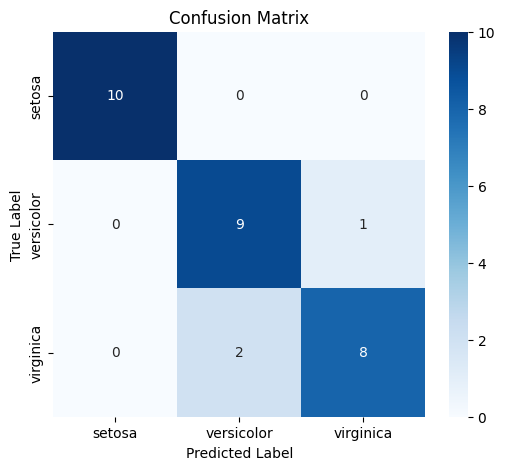

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



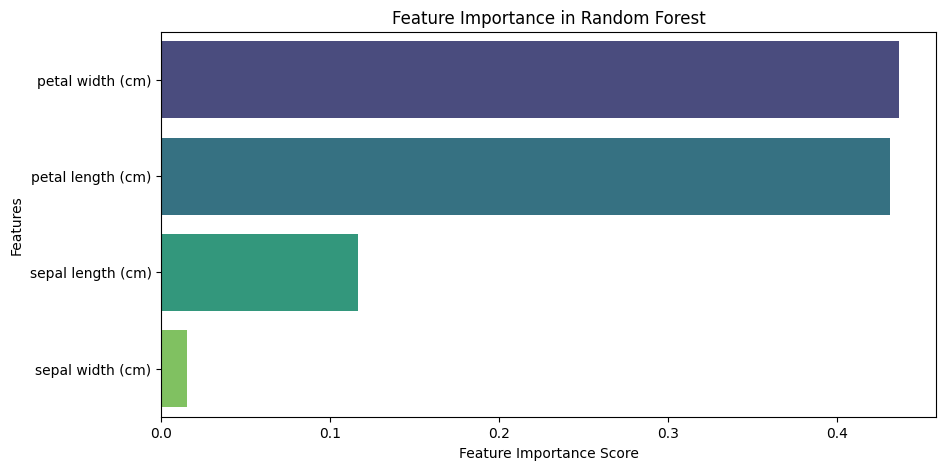

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# 1. Load the dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

# 2. Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf.predict(X_test)

# 5. Identify misclassified samples
misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_samples = X_test.iloc[misclassified_indices]
misclassified_labels = y_test.iloc[misclassified_indices].values
misclassified_preds = y_pred[misclassified_indices]

# 6. Print misclassified samples
print("Misclassified Samples:")
print(pd.DataFrame({"Actual": misclassified_labels, "Predicted": misclassified_preds}, index=misclassified_samples.index))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 8. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 9. Feature Importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance_df["Importance"], y=feature_importance_df["Feature"], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.show()


34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.

In [110]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
data.keys()
X=pd.DataFrame(data=data.data, columns=data.feature_names)
Y= data.target
from sklearn.model_selection  import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.3, random_state=1)
from sklearn.tree import DecisionTreeClassifier
DT_model = DecisionTreeClassifier(criterion='gini',max_depth=5)
DT_model.fit(X_train,Y_train)
Y_pred_DT= DT_model.predict(X_test)
from sklearn.ensemble import BaggingClassifier
model=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=10)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
from sklearn.metrics import classification_report
print(f'classification report of decision tree is following {classification_report(Y_pred_DT,Y_test)}')
print(f'classification report of Bagging Classifier is following {classification_report(Y_pred,Y_test)}')

classification report of decision tree is following               precision    recall  f1-score   support

           0       0.86      0.98      0.92        55
           1       0.99      0.92      0.96       116

    accuracy                           0.94       171
   macro avg       0.92      0.95      0.94       171
weighted avg       0.95      0.94      0.94       171

classification report of Bagging Classifier is following               precision    recall  f1-score   support

           0       0.89      0.95      0.92        59
           1       0.97      0.94      0.95       112

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



35.  Train a Random Forest Classifier and visualize the confusion matrix.

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_breast_cancer

In [3]:
data=load_breast_cancer()

In [4]:
X=pd.DataFrame(data.data, columns= data.feature_names)

In [5]:
Y = data.target

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.3, random_state=1)

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
model = RandomForestClassifier(n_estimators=30,criterion='gini',max_depth=5,max_features=0.5,max_samples=0.7)

In [10]:
model.fit(X_train,Y_train)

RandomForestClassifier(max_depth=5, max_features=0.5, max_samples=0.7,
                       n_estimators=30)

In [11]:
Y_predict = model.predict(X_test)

In [12]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [13]:
con = confusion_matrix(y_true=Y_test, y_pred=Y_predict)

In [14]:
cm = ConfusionMatrixDisplay(confusion_matrix=con,display_labels=model.classes_)

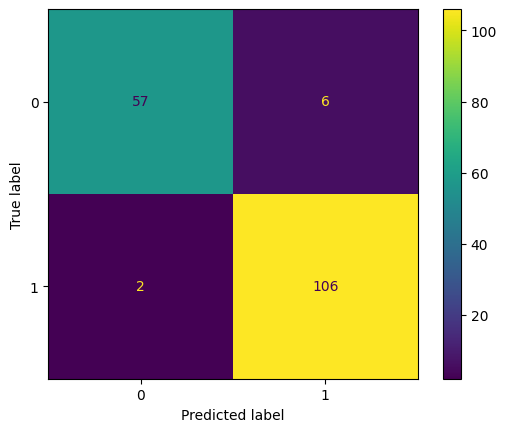

In [18]:
cm.plot()

<Axes: >

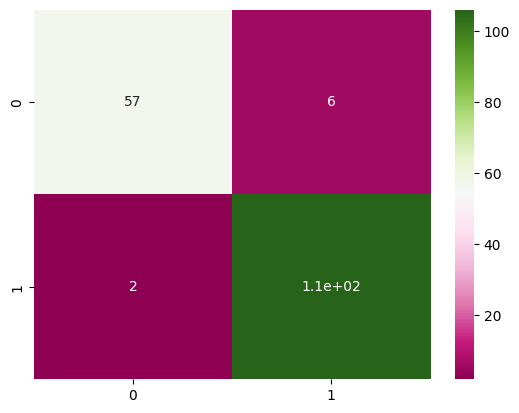

In [17]:
sns.heatmap(con,annot=True,cmap='PiYG')

37.  Train a Random Forest Classifier and print the top 5 most important features

In [21]:
score = model.feature_importances_

In [22]:
name = model.feature_names_in_

In [27]:
dict = {}
for x,y in zip (score,name):
    dict[y] = float(x)

In [28]:
dict

{'mean radius': 0.0022508799239797806,
 'mean texture': 0.01973152418686177,
 'mean perimeter': 0.0030216100721125717,
 'mean area': 0.0038260819390539655,
 'mean smoothness': 0.003109256584707782,
 'mean compactness': 0.0007558206768946113,
 'mean concavity': 0.03493828864593953,
 'mean concave points': 0.0035581830515754843,
 'mean symmetry': 0.003836158409767552,
 'mean fractal dimension': 0.002167315014513863,
 'radius error': 0.0028583669662076696,
 'texture error': 0.002182051535205358,
 'perimeter error': 0.007625458125135513,
 'area error': 0.0034218744685354163,
 'smoothness error': 0.004386838786764416,
 'compactness error': 0.003129395164430021,
 'concavity error': 0.0007886824454552466,
 'concave points error': 0.0007583836007828954,
 'symmetry error': 0.001684379322672458,
 'fractal dimension error': 0.00300153748928245,
 'worst radius': 0.16071871868539273,
 'worst texture': 0.010470326405689597,
 'worst perimeter': 0.337001857035897,
 'worst area': 0.10057609394822917,
 

In [29]:
output = sorted(dict.items() , key= lambda item: item[1], reverse=True)[:5]

In [30]:
print(output)

[('worst perimeter', 0.337001857035897), ('worst concave points', 0.23816638389290842), ('worst radius', 0.16071871868539273), ('worst area', 0.10057609394822917), ('mean concavity', 0.03493828864593953)]


38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
data.keys()
X=pd.DataFrame(data=data.data, columns=data.feature_names)
Y= data.target
from sklearn.model_selection  import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.3, random_state=1)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
model=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=10)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
from sklearn.metrics import classification_report
print(f'classification report of Bagging Classifier is following {classification_report(Y_pred,Y_test)}')

classification report of Bagging Classifier is following               precision    recall  f1-score   support

           0       0.92      0.94      0.93        62
           1       0.96      0.95      0.96       109

    accuracy                           0.95       171
   macro avg       0.94      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



39.  Train a Random Forest Classifier and analyze the effect of max_depth on accuracy

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Define models and parameter grids
models = {
    'RandomForest': (RandomForestClassifier(), {'max_depth': [3, 5, 10,15]}),
    'SVM': (SVC(), {'C': [0.1, 1, 10]})
}

for name, (model, param_grid) in models.items():
    grid = GridSearchCV(model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, Y_train)

    # Extract accuracies
    results = grid.cv_results_
    for mean_score, params in zip(results["mean_test_score"], results["params"]):
        print(f"Model: {name}, Accuracy: {mean_score:.4f}, Params: {params}")


Model: RandomForest, Accuracy: 0.9473, Params: {'max_depth': 3}
Model: RandomForest, Accuracy: 0.9523, Params: {'max_depth': 5}
Model: RandomForest, Accuracy: 0.9498, Params: {'max_depth': 10}
Model: RandomForest, Accuracy: 0.9548, Params: {'max_depth': 15}
Model: SVM, Accuracy: 0.8768, Params: {'C': 0.1}
Model: SVM, Accuracy: 0.9095, Params: {'C': 1}
Model: SVM, Accuracy: 0.9197, Params: {'C': 10}


40.  Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare
performance.

DecisionTree - MSE: 544.75, R²: 0.86
KNeighbors - MSE: 419.53, R²: 0.89


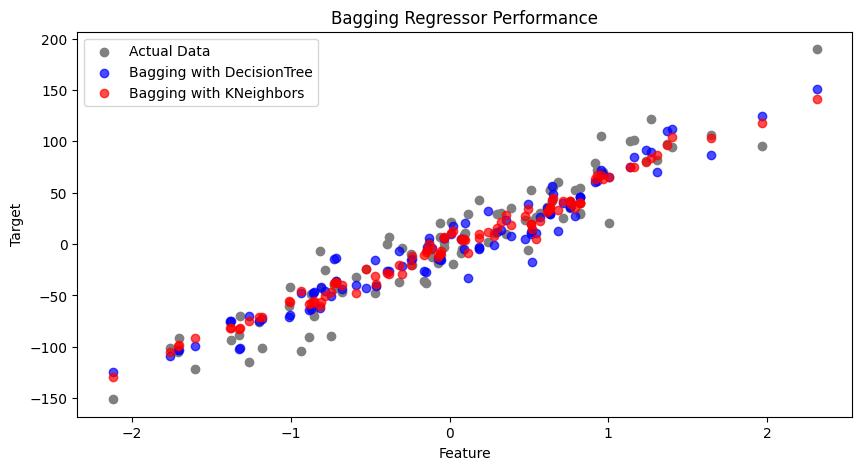

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Data
X, y = make_regression(n_samples=500, n_features=1, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Bagging Regressors
bagging_dt = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)
bagging_knn = BaggingRegressor(estimator=KNeighborsRegressor(), n_estimators=50, random_state=42)

bagging_dt.fit(X_train, y_train)
bagging_knn.fit(X_train, y_train)

# 3. Predictions
y_pred_dt = bagging_dt.predict(X_test)
y_pred_knn = bagging_knn.predict(X_test)

# 4. Performance Metrics
mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_knn = mean_squared_error(y_test, y_pred_knn)

r2_dt = r2_score(y_test, y_pred_dt)
r2_knn = r2_score(y_test, y_pred_knn)

print(f"DecisionTree - MSE: {mse_dt:.2f}, R²: {r2_dt:.2f}")
print(f"KNeighbors - MSE: {mse_knn:.2f}, R²: {r2_knn:.2f}")

# 5. Visualization
plt.figure(figsize=(10,5))
plt.scatter(X_test, y_test, color='gray', label="Actual Data")
plt.scatter(X_test, y_pred_dt, color='blue', label="Bagging with DecisionTree", alpha=0.7)
plt.scatter(X_test, y_pred_knn, color='red', label="Bagging with KNeighbors", alpha=0.7)
plt.legend()
plt.title("Bagging Regressor Performance")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.show()


41. = Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
data.keys()
X=pd.DataFrame(data=data.data, columns=data.feature_names)
Y= data.target
from sklearn.model_selection  import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X,Y,test_size=0.3, random_state=1)
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
model=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=10)
model.fit(X_train,Y_train)
Y_pred=model.predict(X_test)
from sklearn.metrics import roc_auc_score
print(roc_auc_score(Y_pred, Y_test))


0.9497354497354497


42.  Train a Bagging Classifier and evaluate its performance using cross-validatio.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, random_state=42)

# 2. Split into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Bagging Classifier with Decision Tree as Base Estimator
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
bagging_clf.fit(X_train, y_train)

# 4. Cross-Validation
cv_scores = cross_val_score(bagging_clf, X_train, y_train, cv=5, scoring='accuracy')

# 5. Predictions
y_pred = bagging_clf.predict(X_test)

# 6. Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.2f}")
print(f"Test Set Accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)



Cross-Validation Accuracy Scores: [0.925   0.85625 0.93125 0.91875 0.9375 ]
Mean CV Accuracy: 0.91
Test Set Accuracy: 0.96

Confusion Matrix:
 [[108   4]
 [  3  85]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97       112
           1       0.96      0.97      0.96        88

    accuracy                           0.96       200
   macro avg       0.96      0.97      0.96       200
weighted avg       0.97      0.96      0.97       200



43. Train a Random Forest Classifier and plot the Precision-Recall curve

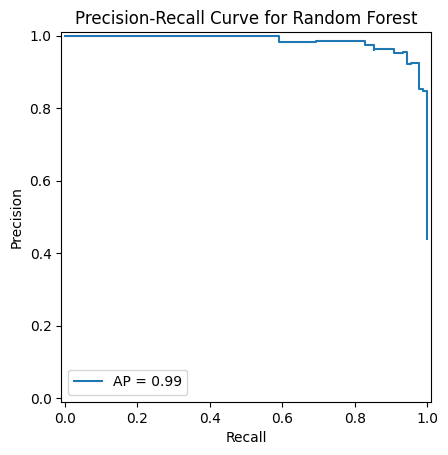

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

# 1. Load Dataset
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, random_state=42)

# 2. Split into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# 4. Get Prediction Probabilities
y_probs = rf_clf.predict_proba(X_test)[:, 1]  # Probability for positive class

# 5. Compute Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_probs)
avg_precision = average_precision_score(y_test, y_probs)

# 6. Plot Precision-Recall Curve
disp = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=avg_precision)
disp.plot()
plt.title("Precision-Recall Curve for Random Forest")
plt.show()


45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

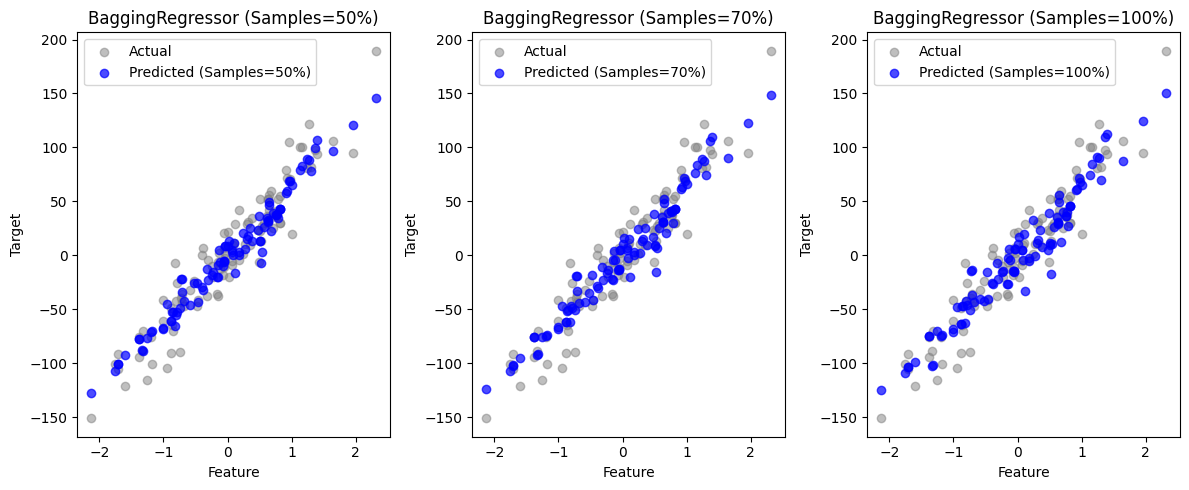

Bootstrap Samples 50% -> MSE: 458.48, R²: 0.88
Bootstrap Samples 70% -> MSE: 483.07, R²: 0.87
Bootstrap Samples 100% -> MSE: 544.75, R²: 0.86


In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load Dataset
X, y = make_regression(n_samples=500, n_features=1, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Different Bootstrap Sample Levels
bootstrap_levels = [0.5, 0.7, 1.0]  # 50%, 70%, 100%
results = {}

plt.figure(figsize=(12, 5))

for i, max_samples in enumerate(bootstrap_levels):
    # 2. Train Bagging Regressor with Varying Bootstrap Samples
    bagging_reg = BaggingRegressor(estimator=DecisionTreeRegressor(),
                                   n_estimators=50,
                                   max_samples=max_samples,
                                   random_state=42)
    bagging_reg.fit(X_train, y_train)
    
    # 3. Predictions
    y_pred = bagging_reg.predict(X_test)
    
    # 4. Performance Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[max_samples] = (mse, r2)
    
    # 5. Plot Predictions
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_test, y_test, color='gray', alpha=0.5, label="Actual")
    plt.scatter(X_test, y_pred, color='blue', label=f"Predicted (Samples={max_samples*100:.0f}%)", alpha=0.7)
    plt.xlabel("Feature")
    plt.ylabel("Target")
    plt.legend()
    plt.title(f"BaggingRegressor (Samples={max_samples*100:.0f}%)")

plt.tight_layout()
plt.show()

# 6. Print Performance Metrics
for max_samples, (mse, r2) in results.items():
    print(f"Bootstrap Samples {max_samples*100:.0f}% -> MSE: {mse:.2f}, R²: {r2:.2f}")
